In [1]:
!pip install torch==2.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.7 MB/s eta 0:00:00


In [3]:
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.5.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 61.6 MB/s eta 0:00:00


In [4]:
!pip install awkward

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 24.7 MB/s eta 0:00:00


In [5]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/Advanced_deep_learning')

In [7]:
pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-umkbm5cc
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-umkbm5cc
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done
  Created wheel for jammy_flows: filename=jammy_flows-1.0.0-py3-none-any.whl size=174322 sha256=4fe594cbec321270ebf8789bf436d4a8c45fa776bc8f2c05886741eb21310354
  Stored in directory: /tmp/pip-ephem-wheel-cache-86de_n59/wheels/c0/ce/35/60016f460c07fecc64f55db2a40862c9add349fb0620845532
Successfully built jammy_flows


In [8]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool
from scipy.stats import norm
import jammy_flows

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [9]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# Useful functions #

In [10]:
def normalize(labels, p):
    """
    Normalize the input labels using percentile-based scaling.

    This function scales the input labels to a range of [0, 1] based on the specified percentiles.
    The scaling is done by computing the percentiles of the labels and then normalizing the labels
    using these percentile values. The percentiles are decimals, we use these boundaries as the min/max
    of the dataset could be related to very rare data due to fluctuations, we want to identify a range
    in which are contained most of the data.

    Parameters:
    labels (np.ndarray): The input labels to be normalized.
    p (float): The percentile value used for scaling. The function uses the p-th and (1-p)-th percentiles
               for normalization.

    Returns:
    tuple: A tuple containing the normalized labels and the range used for normalization.
           - normalized_labels (np.ndarray): The normalized labels.
           - ranges (np.ndarray): The range used for normalization, which includes the p-th and (1-p)-th percentiles.
    """
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

In [11]:
# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):
    """
    Denormalize the input labels using the specified range.

    This function denormalizes the input labels using the specified range values.
    The denormalization is done by scaling the labels back to the original range
    using the provided range values.

    Parameters:
        labels (np.ndarray): The normalized labels to be  denormalized.
        ranges (np.ndarray): The range values used for normalization.

    Returns:
        np.ndarray: The denormalized labels.
    """
    return labels * (ranges[1] - ranges[0]) + ranges[0]


In [12]:
def denormalize_std(uncertainty, ranges):
    """
    Denormalizes the given uncertainty predictions using the provided range.

    It is different to the denormalization of the labels which also includes a shift, as
    the uncertainty is a range and is independent from shifting.

    Parameters
    ----------
    uncertainty : array-like
        The normalized uncertainty to be denormalized.
    ranges : array-like
        A two-element array-like object where the first element is the minimum value
        and the second element is the maximum value of the original range.
    Returns
    -------
    array-like
        The denormalized uncertainty.
    """

    return uncertainty * (ranges[1] - ranges[0])

In [13]:
def plot_loss(N_epochs, train_loss, eval_loss):
  plt.figure(figsize = (10,10))
  plt.xlabel('Number of epochs')
  plt.ylabel('Loss function')
  plt.plot(range(N_epochs), train_loss, color = 'red', label = 'Training')
  plt.plot(range(N_epochs), eval_loss, color = 'green', label = 'Validation')
  plt.legend(fontsize = 10)
  plt.show()

In [14]:
def plot_results(denorm_true_labels, denorm_predictions, labels_name, denorm_std, colors):
  N_labels = denorm_true_labels.shape[1]

  fig,ax = plt.subplots(nrows = 3, ncols = N_labels, figsize = (15,18))
  ax = ax.flatten()

  min_pred = np.min([denorm_predictions[:, 0], denorm_predictions[:, 1]])
  max_pred = np.max([denorm_predictions[:, 0], denorm_predictions[:, 1]])
  min_true = np.min([denorm_true_labels[:, 0], denorm_true_labels[:, 1]])
  max_true = np.max([denorm_true_labels[:, 0], denorm_true_labels[:, 1]])

  ax[0].set_ylim(min_pred, max_pred)
  ax[1].set_ylim(min_pred, max_pred)
  ax[0].set_xlim(min_true, max_true)
  ax[1].set_xlim(min_true, max_true)

  for i in range(N_labels):
    ax[i].set_xlabel('Real Data')
    ax[i].set_ylabel('Prediction')
    ax[i].set_title(labels_name[i])
    ax[i].scatter(denorm_true_labels[:,i],denorm_predictions[:,i], color = colors[i], s = 10, label = 'data')
    ax[i].axline((denorm_true_labels[:,i].min(), denorm_true_labels[:,i].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
    ax[i].legend(fontsize = 10)

  for i in range(N_labels,N_labels*2):
    ax[i].set_xlabel('Uncertainty values')
    ax[i].set_ylabel('Entries')
    ax[i].hist(denorm_std[:,0], bins = 50, color = colors[i-2])

  pull_val = (denorm_predictions - denorm_true_labels)/denorm_std

  for i in range(N_labels*2, N_labels*3):
    counts, bin_edges = np.histogram(pull_val[:,i-4], bins=50,range = (-5,5), density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
    mu, std = norm.fit(pull_val[:,i-4]) #Built in function for gaussian fit of data, computes their mean and standard deviation
    x_range = np.linspace(bin_edges[0], bin_edges[-1], 100) #Define an arbitrary x_range to plot the fitted curve
    curve_fit = norm.pdf(x_range, mu, std) #Define points distributed on the computed gaussian for the defined range

    ax[i].hist(pull_val[:,i-4], bins=50, density=True, color=colors[i-4], label = 'Pull distribution entries')
    ax[i].plot(x_range, curve_fit, 'black', lw=2, label=f'Gaussian fit\n mean={mu:.2f}, std={std:.2f}')
    ax[i].set_xlim(-5,5)
    ax[i].set_xlabel('(Predicted-True)/Uncertainty')
    ax[i].set_ylabel('Entries')
    ax[i].legend(fontsize = 10)

  plt.show()

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


In [16]:
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_4/IceCube 2D Dataset'

#IceCube dataset exploration #

The IceCube dataset contains quantities related to neutrino motion measured using 5000 photodetection units:

* **xpos,ypos** $\to$ position in the x-y plane;
* **data** $\to$ photons registered by every detection unit for a given event. As every event can create a different number of photons, awkward arrays (non-fixed dimension arrays) are considered;
* **energy** $\to$ the neutrino energy;
* **xdir,ydir** the direction of motion on the x-y plane.

The goal is to train a GNN to learn how to predict the neutrino positions **xpos,ypos** (labels) from the photon hits **data** (features).

In [17]:
# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [18]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}


In [19]:
# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]


In [20]:
# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x = -2.5, y = -2.5
Hit 2: time = 8.996675814194964, x = 2.5, y = -2.5
Hit 3: time = 12.021784213609394, x = 2.5, y = -2.5
Hit 4: time = 12.923289636173713, x = 2.5, y = -2.5
Hit 5: time = 25.1516276582378, x = -2.5, y = -0.8333333333333333
Hit 6: time = 15.286326473533162, x = 0.8333333333333335, y = -0.8333333333333333
Hit 7: time = 15.14788039212255, x = 2.5, y = -0.8333333333333333
Hit 8: time = 16.565114961505415, x = -0.8333333333333333, y = 0.8333333333333335
Hit 9: time = 19.47621700139486, x = -0.8333333333333333, y = 0.8333333333333335
Hit 10: time = 16.912010076540938, x = 2.5, y = 2.5
Hit 11: time = 19.57845737402364, x = 2.5, y = 2.5
The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has the

In [21]:
import awkward

###### Calculate statistics (ONLY on the Training dataset) ######

times_t = train_dataset["data"][:, 0:1, :]
x_t = train_dataset["data"][:, 1:2, :]
y_t = train_dataset["data"][:, 2:3, :]

# awkward.mean() calculates the mean over all flattened elements
mean_time, std_time = awkward.mean(times_t), awkward.std(times_t)
mean_x, std_x = awkward.mean(x_t), awkward.std(x_t)
mean_y, std_y = awkward.mean(y_t), awkward.std(y_t)

# Avoid division by zero in case a feature is constant
std_time = std_time if std_time > 0 else 1.0
std_x = std_x if std_x > 0 else 1.0
std_y = std_y if std_y > 0 else 1.0

###### Training dataset (Application) ######

norm_times_t = (times_t - mean_time) / std_time
norm_x_t = (x_t - mean_x) / std_x
norm_y_t = (y_t - mean_y) / std_y

train_dataset["data"] = awkward.concatenate([norm_times_t, norm_x_t, norm_y_t], axis=1)

###### Validation dataset ######

times_v = val_dataset["data"][:, 0:1, :]
x_v = val_dataset["data"][:, 1:2, :]
y_v = val_dataset["data"][:, 2:3, :]

# We use the mean and std calculated on the TRAINING set
norm_times_v = (times_v - mean_time) / std_time
norm_x_v = (x_v - mean_x) / std_x
norm_y_v = (y_v - mean_y) / std_y

val_dataset["data"] = awkward.concatenate([norm_times_v, norm_x_v, norm_y_v], axis=1)

###### Test dataset ######

times_te = test_dataset["data"][:, 0:1, :]
x_te = test_dataset["data"][:, 1:2, :]
y_te = test_dataset["data"][:, 2:3, :]

#  We use the mean and std calculated on the TRAINING set
norm_times_te = (times_te - mean_time) / std_time
norm_x_te = (x_te - mean_x) / std_x
norm_y_te = (y_te - mean_y) / std_y

test_dataset["data"] = awkward.concatenate([norm_times_te, norm_x_te, norm_y_te], axis=1)

In [22]:
# Normalize labels

###### Training dataset ######

x_pos_norm_t, range_x_t = normalize(train_dataset["xpos"], 0.05)
y_pos_norm_t, range_y_t = normalize(train_dataset["ypos"], 0.05)

train_dataset["xpos"] = x_pos_norm_t
train_dataset["ypos"] = y_pos_norm_t

###### Validation dataset ######

x_pos_norm_v, range_x_v = normalize(val_dataset["xpos"], 0.05)
y_pos_norm_v, range_y_v = normalize(val_dataset["ypos"], 0.05)

val_dataset["xpos"] = x_pos_norm_v
val_dataset["ypos"] = y_pos_norm_v

###### Test dataset ######

x_pos_norm_te, range_x_te = normalize(test_dataset["xpos"], 0.05)
y_pos_norm_te, range_y_te = normalize(test_dataset["ypos"], 0.05)

test_dataset["xpos"] = x_pos_norm_te
test_dataset["ypos"] = y_pos_norm_te

# Prepare the data for training #

In [23]:
# Create the DataLoader for training, validation, and test datasets
# Important: We use the custom collate function to preprocess the data for GNN
def collate_fn_gnn(batch):
    """
    Custom function that defines how batches are formed.

    For a more complicated dataset with variable length per event and Graph Neural Networks,
    we need to define a custom collate function which is passed to the DataLoader.
    The default collate function in PyTorch Geometric is not suitable for this case.

    This function takes the Awkward arrays, converts them to PyTorch tensors,
    and then creates a PyTorch Geometric Data object for each event in the batch.

    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        # for training a GNN, we need the graph notes, i.e., the individual hits, as the first dimension,
        # so we need to transpose to get (n_hits, n_features): in this way, every graph has a variable node number
        #but every node has exactly 3 features: time, position x, position y
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        # PyTorch Geometric needs the data in a specific format
        # we need to create a PyTorch Geometric Data object for each event
        this_graph_item = Data(x=tensordata) #Each event is considered as a graph and stored in a list of graphs
        data_list.append(this_graph_item)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor
    packed_data = Batch.from_data_list(data_list) # convert the list of Data objects to a single Batch object
    return packed_data, labels

In [24]:
batch_size = 128

In [25]:
# Each batch contains more events, graphs for different events will be united in the same super-graph in order to the model to analyze them simoultaneously, but the
#object will record which node is associated to which graph

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

# Model definition #

The graph is built using the "k-nearest neighbors" principle, then the model consists in a dynamic edge convolution on it: for each node the features are evolved by aggregating the edge features computed for each of the neighbors. How the node and neighbor features are combined is predicted by a neural network (in this case a multilayer perceptron). The convolution kernel is not fixed but is evolved during the computation to maximize the model performance. For every dataset, I create 10001 graph (each associated to a hit event) with a variable number of nodes each with 3 features.

In [26]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim_1, hidden_dim_2, output_dim):
        super(MLP, self).__init__()

        self.fc = nn.Sequential(
        nn.Linear(input_dim, hidden_dim_1),
        nn.BatchNorm1d(hidden_dim_1),
        nn.ReLU(),
        nn.Linear(hidden_dim_1, hidden_dim_2),
        nn.BatchNorm1d(hidden_dim_2),
        nn.ReLU(),
        nn.Linear(hidden_dim_2, output_dim),
        )

    def forward(self, x):
        x = self.fc(x)
        return x

In [27]:
# Defintion of the GNN model
# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feauture dimension of this graph layer.

from torch_geometric.nn import DynamicEdgeConv

class GNNEncoder(nn.Module):
    def __init__(self, k, output_dim):
        super(GNNEncoder, self).__init__()

        self.layer_1 = DynamicEdgeConv(
                    MLP(6, 128, 64, 20),   # input 6 features as each time the model considers two nodes
                    aggr='mean', k=k,  # k is the number of nearest neighbors to consider
                )

        self.layer_2 = DynamicEdgeConv(
                    MLP(40, 256, 128, 20), # still the input features must be twice the output of the previous layer
                    aggr='mean', k=k,  # k is the number of nearest neighbors to consider
                )

        self.layer_3 = DynamicEdgeConv(
                    MLP(40, 256, 128, output_dim),
                    aggr='mean', k=k,  # k is the number of nearest neighbors to consider
                )

        self.layer_list = nn.ModuleList([self.layer_1, self.layer_2, self.layer_3])

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch #list of indices which indicate to which graph (event) each node corresponds in order to not confuse them while computing the prediction

        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)

        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)-> each prediction for every node is transformed in a single prediction for the whole graph, thanks to "batch"
        #information the mean is done for each event separately, so for the batch we have a prediction for each of the indices in data.batch i.e. for each of the events
        # in the batch

        return x

# 1. Prediction without uncertainties #

Firstly the model is trained to predict the labels only without associated uncertainties. The loss used is the MSELoss.

In [28]:
# Model selection
model_choice = 'GNNEncoder'

if model_choice == 'GNNEncoder':
    model_1 = GNNEncoder(5,2)
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_1.to(device)

GNNEncoder(
  (layer_1): DynamicEdgeConv(nn=MLP(
    (fc): Sequential(
      (0): Linear(in_features=6, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=20, bias=True)
    )
  ), k=5)
  (layer_2): DynamicEdgeConv(nn=MLP(
    (fc): Sequential(
      (0): Linear(in_features=40, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=20, bias=True)
    )
  ), k=5)
  (layer_3): DynamicEd

In [29]:
loss_1 = nn.MSELoss()

In [30]:
N_epochs_1 = 60
learning_rate_1 = 0.0001

In [31]:
optimizer_1 = optim.Adam(model_1.parameters(), lr = learning_rate_1)

In [32]:
train_loss_1 = []
eval_loss_1 = []

#-------Training-------
for epoch in range(N_epochs_1):
  start_time = time.time()  # Start the timer for this epoch

  model_1.train()
  loss_val = []

  for step,(features,labels) in enumerate(train_loader): # The DataLoader returns a single object of type Batch
    features = features.to(device) #put data on GPU
    label = labels.to(device)
    output = model_1(features) #The forward function already extracts data.x (features) in the model definition
    loss = loss_1(output,label) #loss computation
    loss_val.append(loss.item())

    optimizer_1.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer_1.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs_1}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss_1.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model_1.eval()
    loss_val = []
    for features,labels in val_loader:
      features = features.to(device)
      labels = labels.to(device)
      output = model_1(features)
      loss = loss_1(output,labels)
      loss_val.append(loss.item())

    eval_loss_1.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [70/79], Loss: 0.0579
Epoch [2/60], Step [70/79], Loss: 0.0212
Epoch [3/60], Step [70/79], Loss: 0.0194
Epoch [4/60], Step [70/79], Loss: 0.0164
Epoch [5/60], Step [70/79], Loss: 0.0143
Epoch [6/60], Step [70/79], Loss: 0.0158
Epoch [7/60], Step [70/79], Loss: 0.0124
Epoch [8/60], Step [70/79], Loss: 0.0135
Epoch [9/60], Step [70/79], Loss: 0.0126
Epoch [10/60], Step [70/79], Loss: 0.0113
Epoch [11/60], Step [70/79], Loss: 0.0125
Epoch [12/60], Step [70/79], Loss: 0.0163
Epoch [13/60], Step [70/79], Loss: 0.0165
Epoch [14/60], Step [70/79], Loss: 0.0120
Epoch [15/60], Step [70/79], Loss: 0.0105
Epoch [16/60], Step [70/79], Loss: 0.0100
Epoch [17/60], Step [70/79], Loss: 0.0125
Epoch [18/60], Step [70/79], Loss: 0.0152
Epoch [19/60], Step [70/79], Loss: 0.0136
Epoch [20/60], Step [70/79], Loss: 0.0134
Epoch [21/60], Step [70/79], Loss: 0.0131
Epoch [22/60], Step [70/79], Loss: 0.0093
Epoch [23/60], Step [70/79], Loss: 0.0130
Epoch [24/60], Step [70/79], Loss: 0.0088
E

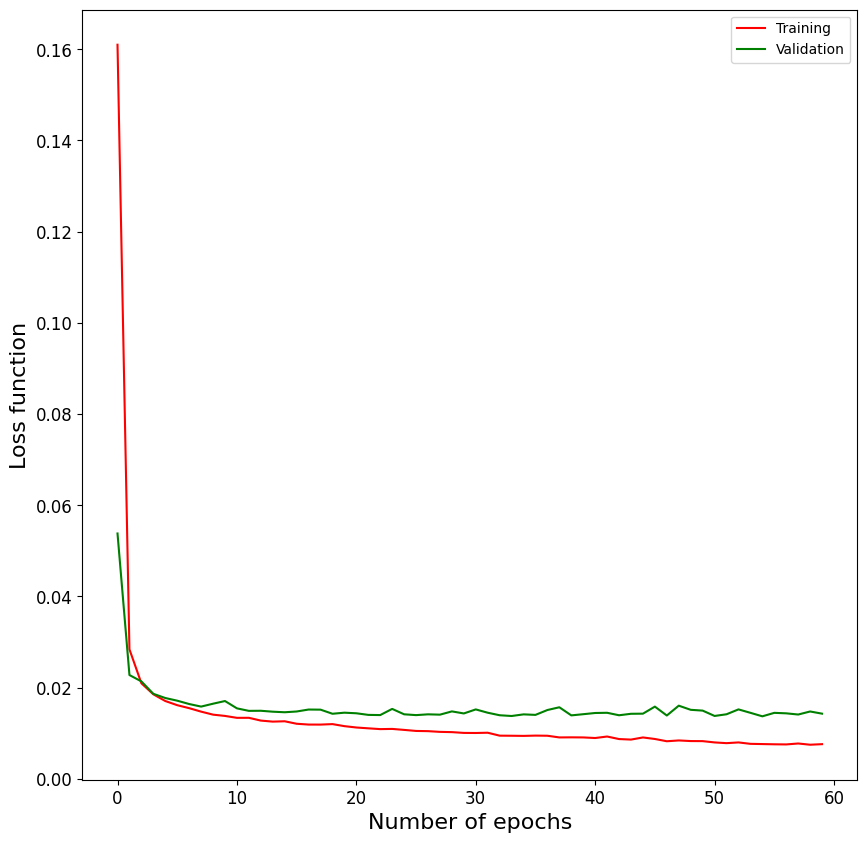

In [33]:
plot_loss(N_epochs_1, train_loss_1, eval_loss_1)

In [34]:
predictions_1 = []
targets_1 = []
test_loss_1 = []

with torch.no_grad():
  model_1.eval()
  for feature,label in test_loader:
    feature = feature.to(device)
    label = label.to(device)
    output = model_1(feature)
    loss = loss_1(output,label)
    test_loss_1.append(loss.item())

    predictions_1.append(output.cpu())
    targets_1.append(label.cpu())

pred_1 = torch.cat(predictions_1, dim=0).numpy()
real_1 = torch.cat(targets_1, dim=0).numpy()

avrg_test_loss_1 = np.mean(test_loss_1)

print(f'Average test loss: {avrg_test_loss_1:.4f}')

Average test loss: 0.0137


In [35]:
denorm_predictions_x = denormalize(pred_1[:,0], range_x_te)  # Denormalize predictions
denorm_predictions_y = denormalize(pred_1[:,1], range_y_te)  # Denormalize predictions
denorm_predictions_1 = np.column_stack((denorm_predictions_x, denorm_predictions_y))
denorm_true_labels_x = denormalize(real_1[:,0], range_x_te)  # Denormalize true labels
denorm_true_labels_y = denormalize(real_1[:,1], range_y_te)  # Denormalize true labels
denorm_true_labels_1 = np.column_stack((denorm_true_labels_x, denorm_true_labels_y))

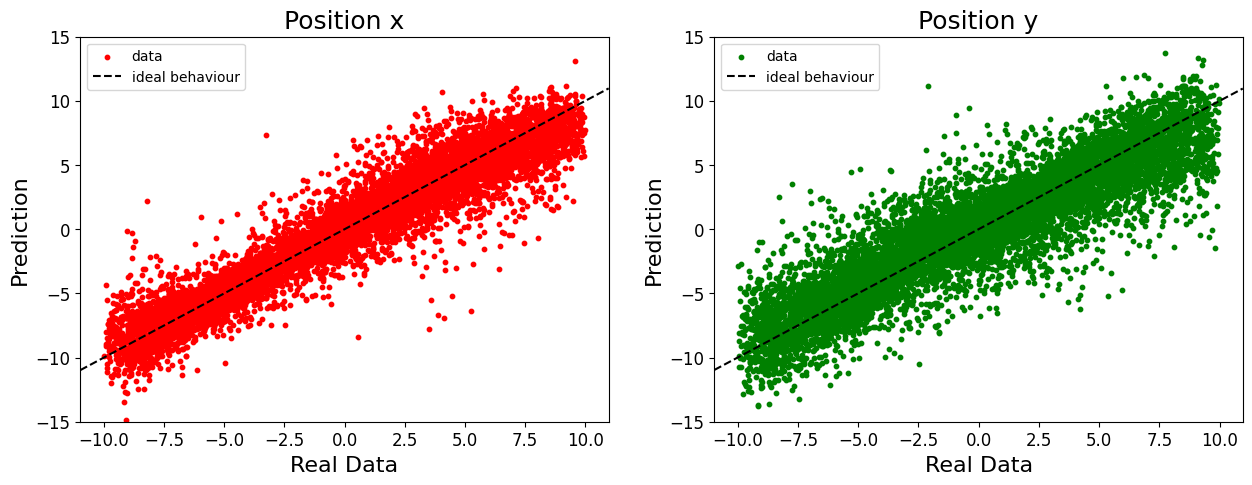

In [36]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))
ax = ax.flatten()

ax[0].set_ylim(-15,15)
ax[1].set_ylim(-15,15)

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('Position x')
ax[0].scatter(denorm_true_labels_1[:,0],denorm_predictions_1[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels_1[:,0].min(), denorm_true_labels_1[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('Position y')
ax[1].scatter(denorm_true_labels_1[:,1],denorm_predictions_1[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels_1[:,1].min(), denorm_true_labels_1[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)

plt.show()

# 2. Gaussian Uncertainty prediction #

The mean and standard deviation of a the best gaussian distribution describing each label will be predicting through a negative log likelihood loss function

In [37]:
def loss_likelihood(output, label, n_labels):
  mean = output[:,:n_labels] #The predicted values correspond to the first half of the output values of the model
  log_std = output[:,n_labels:] #The predicted logarithms of the gaussian uncertainties are the second half of the output values of the model
  std = torch.exp(log_std) #Convertion of the logarithms of the uncertainties into the uncertainties
  return torch.mean((0.5*((label-mean)/std)**2)+log_std) #Likelihood problem solution, considered loss function, average on the three labels

In [38]:
# Model selection
model_choice = 'GNNEncoder'

if model_choice == 'GNNEncoder':
    model_2 = GNNEncoder(5,4)
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_2.to(device)

GNNEncoder(
  (layer_1): DynamicEdgeConv(nn=MLP(
    (fc): Sequential(
      (0): Linear(in_features=6, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=20, bias=True)
    )
  ), k=5)
  (layer_2): DynamicEdgeConv(nn=MLP(
    (fc): Sequential(
      (0): Linear(in_features=40, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=20, bias=True)
    )
  ), k=5)
  (layer_3): DynamicEd

In [39]:
N_epochs_2 = 60
learning_rate_2 = 0.0001

In [40]:
optimizer_2 = optim.Adam(model_2.parameters(), lr = learning_rate_2)

In [41]:
train_loss_2 = []
eval_loss_2 = []

#-------Training-------
for epoch in range(N_epochs_2):
  start_time = time.time()  # Start the timer for this epoch

  model_2.train()
  loss_val = []

  for step,(features,labels) in enumerate(train_loader): # The DataLoader returns a single object of type Batch
    features = features.to(device) #put data on GPU
    label = labels.to(device)
    output = model_2(features) #The forward function already extracts data.x (features) in the model definition
    loss = loss_likelihood(output,label,2) #loss computation
    loss_val.append(loss.item())

    optimizer_2.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer_2.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs_2}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss_2.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model_2.eval()
    loss_val = []
    for features,labels in val_loader:
      features = features.to(device)
      labels = labels.to(device)
      output = model_2(features)
      loss = loss_likelihood(output,labels,2)
      loss_val.append(loss.item())

    eval_loss_2.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [70/79], Loss: -0.2670
Epoch [2/60], Step [70/79], Loss: -0.7387
Epoch [3/60], Step [70/79], Loss: -1.0028
Epoch [4/60], Step [70/79], Loss: -1.2532
Epoch [5/60], Step [70/79], Loss: -1.4756
Epoch [6/60], Step [70/79], Loss: -1.6217
Epoch [7/60], Step [70/79], Loss: -1.7548
Epoch [8/60], Step [70/79], Loss: -1.7781
Epoch [9/60], Step [70/79], Loss: -1.7294
Epoch [10/60], Step [70/79], Loss: -1.8541
Epoch [11/60], Step [70/79], Loss: -1.8183
Epoch [12/60], Step [70/79], Loss: -1.8941
Epoch [13/60], Step [70/79], Loss: -1.9924
Epoch [14/60], Step [70/79], Loss: -1.9507
Epoch [15/60], Step [70/79], Loss: -1.9712
Epoch [16/60], Step [70/79], Loss: -1.9233
Epoch [17/60], Step [70/79], Loss: -1.9399
Epoch [18/60], Step [70/79], Loss: -1.8452
Epoch [19/60], Step [70/79], Loss: -1.8943
Epoch [20/60], Step [70/79], Loss: -1.9572
Epoch [21/60], Step [70/79], Loss: -1.9752
Epoch [22/60], Step [70/79], Loss: -2.0310
Epoch [23/60], Step [70/79], Loss: -2.1165
Epoch [24/60], Step 

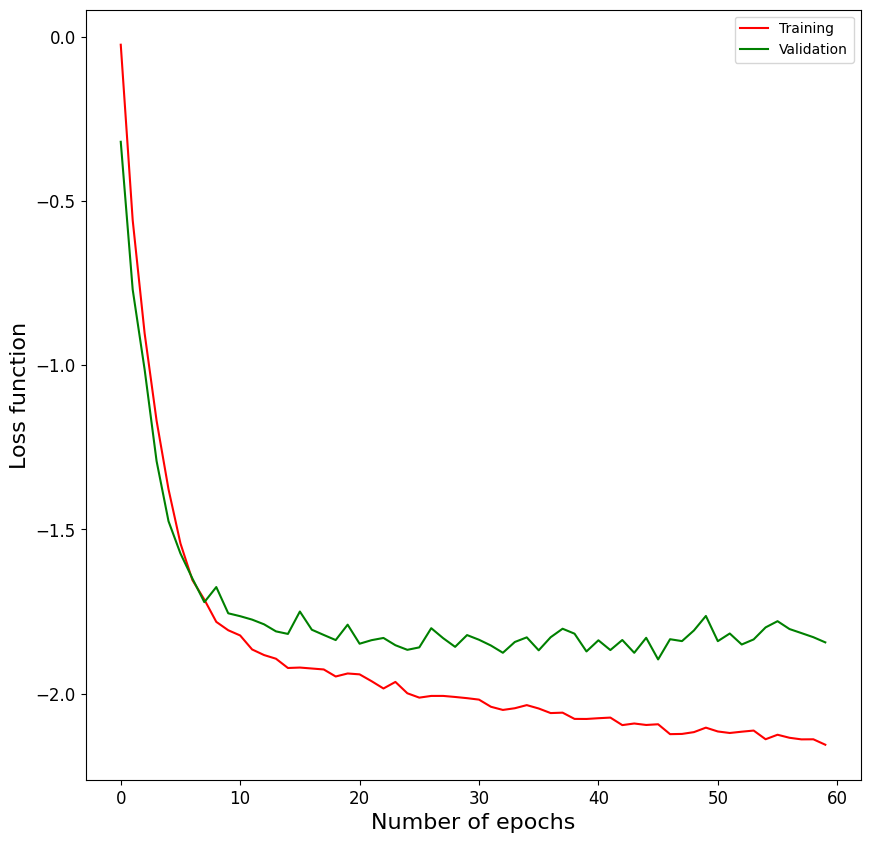

In [42]:
plot_loss(N_epochs_2, train_loss_2, eval_loss_2)

In [43]:
predictions_2 = []
targets_2 = []
test_loss_2 = []

with torch.no_grad():
  model_2.eval()
  for feature,label in test_loader:
    feature = feature.to(device)
    label = label.to(device)
    output = model_2(feature)
    loss = loss_likelihood(output,label,2)
    test_loss_2.append(loss.item())

    predictions_2.append(output.cpu())
    targets_2.append(label.cpu())

pred_2 = torch.cat(predictions_2, dim=0).numpy()
real_2 = torch.cat(targets_2, dim=0).numpy()

avrg_test_loss_2 = np.mean(test_loss_2)

print(f'Average test loss: {avrg_test_loss_2:.4f}')

Average test loss: -1.8722


In [44]:
denorm_predictions_x_2 = denormalize(pred_2[:,0], range_x_te)  # Denormalize predictions
denorm_predictions_y_2 = denormalize(pred_2[:,1], range_y_te)  # Denormalize predictions
denorm_predictions_2 = np.column_stack((denorm_predictions_x_2, denorm_predictions_y_2))
denorm_true_labels_x_2 = denormalize(real_2[:,0], range_x_te)  # Denormalize true labels
denorm_true_labels_y_2 = denormalize(real_2[:,1], range_y_te)  # Denormalize true labels
denorm_true_labels_2 = np.column_stack((denorm_true_labels_x_2, denorm_true_labels_y_2))
denorm_std_x_2 = denormalize_std(np.exp(pred_2[:,2]), range_x_te) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_std_y_2 = denormalize_std(np.exp(pred_2[:,3]), range_y_te)
denorm_std_2 = np.column_stack((denorm_std_x_2, denorm_std_y_2))

In [45]:
labels_name = ['Position x', 'Position y']
colors = ['red', 'green']

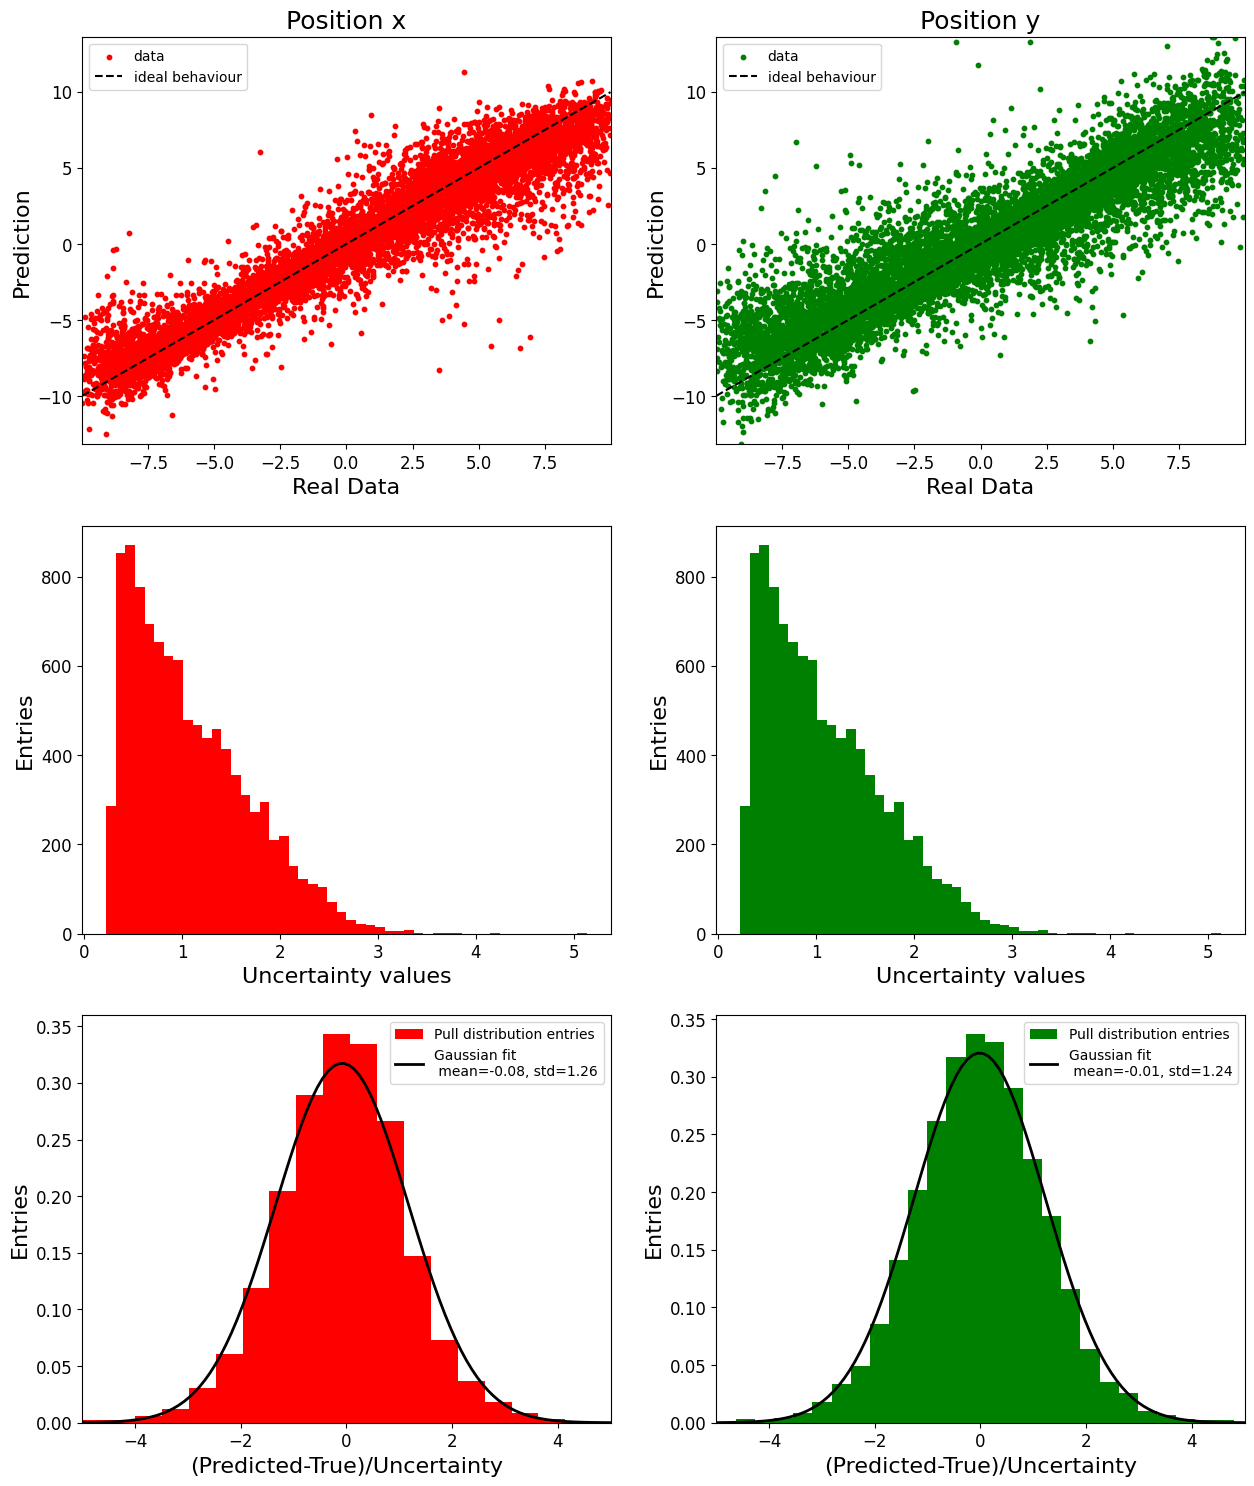

In [46]:
plot_results(denorm_true_labels_2, denorm_predictions_2, labels_name, denorm_std_2, colors)

# 3. Uncertainty prediction through a normalizing flow #

The graph neural network will now be trained to predict the parameters of a normalizing flow to go from a standard gaussian to an arbitrary distribution describing each label.

In [47]:
def nf_loss(input, batch_labels, model):
    """
    Computes the loss for a normalizing flow model. Here already the predictions of the model (log_pdf) are computed, no need to use forward function for training,
    in this case the forward is used only to predict parameters but in the training what counts is the value of the PDF, the neural network is not predicting the labels.

    Parameters
    ----------
    input : torch.Tensor
        The input data of the model.
    batch_labels : torch.Tensor
        The labels corresponding to the input data.
    model : torch.nn.Module
        The normalizing flow model used for evaluation.
    Returns
    -------
    torch.Tensor
        The computed loss value.
    """
    log_pdfs = model.log_pdf_evaluation(batch_labels, input) # get the probability of the labels given the input data
    loss = -log_pdfs.mean() # take the negative mean of the log probabilities
    return loss

In [48]:
fp64_on_cpu = False

In [49]:
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a CNN encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        """
        Initializes the normalizing flow model.

        Parameters
        ----------
        encoder : callable
            A function or callable object that returns an encoder model. The encoder model
            should take the number of flow parameters as input and output the latent dimension.
            I.e. the `TinyCNNEncoder` class defined above.
        nf_type : str, optional
            The type of normalizing flow to use. Options are "diagonal_gaussian", "full_gaussian",
            and "full_flow". Default is "diagonal_gaussian".
        Raises
        ------
        Exception
            If an unknown `nf_type` is provided.
        Notes
        -----
        This method sets up a 3-dimensional probability density function (PDF) over Euclidean space (e3)
        using the specified normalizing flow type. The flow structure and options are configured based on
        the provided `nf_type`. The PDF is created using the `jammy_flows` library, and the number of flow
        parameters is determined and printed. The encoder is initialized with the number of flow parameters.
        """

        super().__init__()

        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 2d PDF (e2) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e2", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to the number of flow parameters
        self.encoder = encoder(5,num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        """
        Evaluate the log probability density function (PDF) for the given target labels and input data.

        The normalizing flow parameters are predicted by the encoder network based on the input data.
        Then, the log PDF is evaluated at the position of the label.

        Parameters:
        -----------
        target_labels : torch.Tensor
            The target labels for which the log PDF is to be evaluated.
        input_data : torch.Tensor
            The input data to be encoded and used for evaluating the log PDF.
        Returns:
        --------
        log_pdf : torch.Tensor
            The evaluated log PDF for the given target labels and input data.
        """
        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
            # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
            if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                target_labels = target_labels.cpu().to(torch.float64)
            else:
                latent_intermediate = latent_intermediate.to(torch.float64)
                target_labels = target_labels.to(torch.float64)

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        """
        Sample new points from the PDF given input data. For every target the parameters predicted for the folw are different. We need to sample for every single
        distribution remembering from which distribution we sampled. The use of 'repeat interleave' allows to generate the samples for each target distribution
        in parallel, intead of generating all the samples for one target and then go to the next one.

        Parameters
        ----------
        flow_params : tensor
            Parameters for the normalizing flow, must be of shape (B, L) where B is the batch size and L is the latent dimension.
        samplesize_per_batchitem : int, optional
            Number of samples to draw per batch item. Defaults to 1000.

        Returns
        -------
        tensor
            A tensor of shape (B, S, D) where B is the batch dimension (position of the target in the given batch), S is the number of samples,
            and D is the dimension of the target space for the samples.
        """
        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
            # convert to double
            if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                flow_params = flow_params.cpu().to(torch.float64)
            else:
                flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
            batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):
        """
        Perform a forward pass through the model, predicting the mean and standard deviation of the samples.

        Normalizing flows do not directly predict the target labels. Instead, they predict the parameters of the flow that
        transforms the base distribution to the target distribution. Often, we still want to predict the target labels.
        Then, we can sample from the distribution and form the mean of the samples and their standard deviations.
        This is what this function does. This function is not used to compute the predictions in the training (for complex flows it doesn't return the number of
        parameters of the flow), it is only used to predict means and std.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor.
        Returns
        -------
        torch.Tensor
            A tensor of size (B, D*2) where the first half (size D) are the means,
            the second half (another D) are the standard deviations.
        """
        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1: compute mean and std along dimensions, this method is very useful in diagonal gaussian
        #case but in other cases a more efficient way to deal with uncertainties should be designed
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function)
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """

        #Divide the disconnected graph of a batch into graphs for single events and select one of them
        single_graph = input_data.to_data_list()[batch_index]

        #The encoder takes a Batch object (graph + list of indices that associate each node to each single graph): from the graph for one event we recreate a batch
        #(in this case containing a single event)
        input_bitem = Batch.from_data_list([single_graph]).to(single_graph.x.device)

        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(2, 1, figsize = (10,10))
        for dim_ind in range(2):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                # Gestiamo il target a prescindere che sia un tensore scalare o un array
                true_value = truth[dim_ind].item() if hasattr(truth[dim_ind], 'item') else truth[dim_ind]
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)

In [50]:
# Model selection
model_choice = 'CombinedModel'

if model_choice == 'CombinedModel':
    model_3 = CombinedModel(GNNEncoder,"full_flow")
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_3.to(device)

The normalizing flow has  197  parameters...


CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0-2): 3 x gf_block()
        (3): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): GNNEncoder(
    (layer_1): DynamicEdgeConv(nn=MLP(
      (fc): Sequential(
        (0): Linear(in_features=6, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=20, bias=True)
      )
    ), k=5)
    (layer_2): DynamicEdgeConv(nn=MLP(
      (fc): Sequential(
        (0): Linear(in_features=40, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear

In [51]:
N_epochs_3 = 60
learning_rate_3 = 0.0005

In [52]:
optimizer_3 = optim.Adam(model_3.parameters(), lr = learning_rate_3)

In [53]:
train_loss_3 = []
eval_loss_3 = []

#-------Training-------
for epoch in range(N_epochs_3):
  start_time = time.time()  # Start the timer for this epoch

  model_3.train()
  loss_val = []

  for step,(feature, label) in enumerate(train_loader):
    feature = feature.to(device) #put data on GPU
    label = label.to(device)
    loss = nf_loss(feature,label,model_3) #loss computation
    loss_val.append(loss.item())

    optimizer_3.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer_3.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs_3}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss_3.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model_3.eval()
    loss_val = []
    for feature, label in val_loader:
      feature = feature.to(device)
      label = label.to(device)
      loss = nf_loss(feature,label,model_3)
      loss_val.append(loss.item())

    eval_loss_3.append(np.mean(loss_val))

#------------------------

Epoch [1/60], Step [70/79], Loss: -1.6582
Epoch [2/60], Step [70/79], Loss: -1.6803
Epoch [3/60], Step [70/79], Loss: -2.1566
Epoch [4/60], Step [70/79], Loss: -2.3097
Epoch [5/60], Step [70/79], Loss: -1.8059
Epoch [6/60], Step [70/79], Loss: -2.6967
Epoch [7/60], Step [70/79], Loss: -1.8352
Epoch [8/60], Step [70/79], Loss: -2.3659
Epoch [9/60], Step [70/79], Loss: -2.6268
Epoch [10/60], Step [70/79], Loss: -2.5030
Epoch [11/60], Step [70/79], Loss: -2.3963
Epoch [12/60], Step [70/79], Loss: -2.7253
Epoch [13/60], Step [70/79], Loss: -2.7178
Epoch [14/60], Step [70/79], Loss: -2.9662
Epoch [15/60], Step [70/79], Loss: -2.5311
Epoch [16/60], Step [70/79], Loss: -2.6167
Epoch [17/60], Step [70/79], Loss: -2.6298
Epoch [18/60], Step [70/79], Loss: -2.7490
Epoch [19/60], Step [70/79], Loss: -2.6992
Epoch [20/60], Step [70/79], Loss: -2.9213
Epoch [21/60], Step [70/79], Loss: -2.8179
Epoch [22/60], Step [70/79], Loss: -2.6108
Epoch [23/60], Step [70/79], Loss: -2.8634
Epoch [24/60], Step 

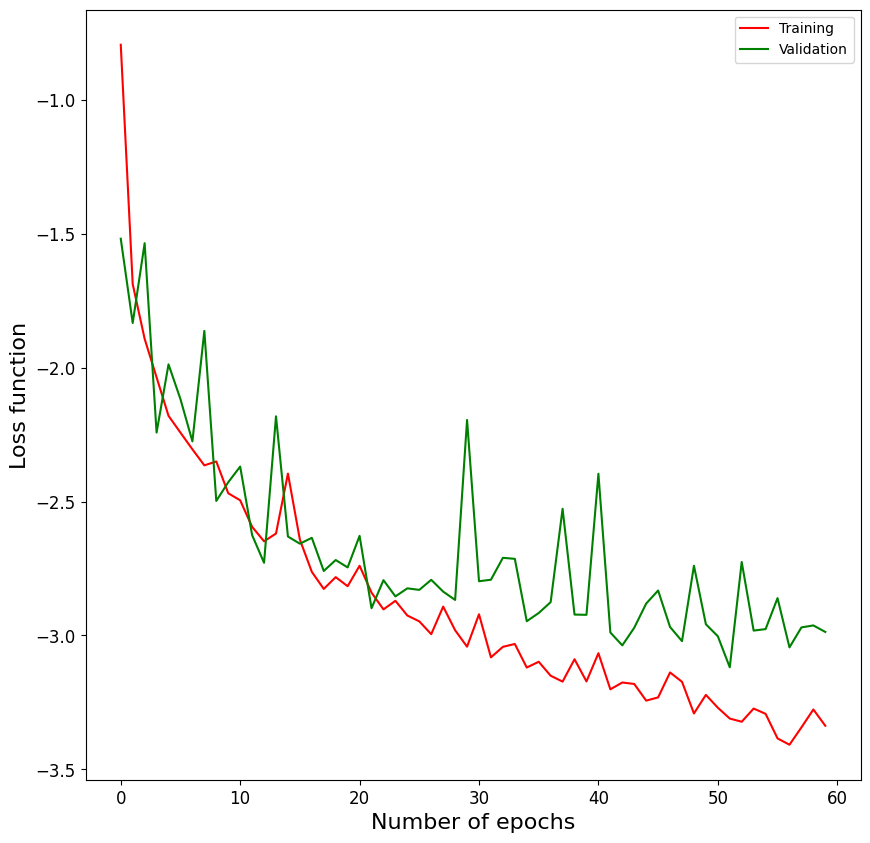

In [54]:
plot_loss(N_epochs_3, train_loss_3, eval_loss_3)

In [55]:
predictions_3 = []
labels_3 = []
test_loss_3 = []

with torch.no_grad():
  model_3.eval()
  for feature,label in test_loader:
    feature = feature.to(device)
    label = label.to(device)
    pred = model_3(feature) #return mean and std of the predicted distributions for every label through sampling
    loss = nf_loss(feature,label,model_3)
    test_loss_3.append(loss.item())
    predictions_3.append(pred.cpu().numpy())
    labels_3.append(label.cpu())

avrg_test_loss_3 = np.mean(test_loss_3)
real_3 = torch.cat(labels_3, dim=0).numpy()
pred_3 = np.concatenate(predictions_3, axis=0)

print(f'Average test loss: {avrg_test_loss_3:.4f}')

Average test loss: -2.9348


In [56]:
denorm_predictions_x_3 = denormalize(pred_3[:,0], range_x_te)  # Denormalize predictions
denorm_predictions_y_3 = denormalize(pred_3[:,1], range_y_te)  # Denormalize predictions
denorm_predictions_3 = np.column_stack((denorm_predictions_x_3, denorm_predictions_y_3))
denorm_true_labels_x_3 = denormalize(real_3[:,0], range_x_te)  # Denormalize true labels
denorm_true_labels_y_3 = denormalize(real_3[:,1], range_y_te)  # Denormalize true labels
denorm_true_labels_3 = np.column_stack((denorm_true_labels_x_3, denorm_true_labels_y_3))
denorm_std_x_3 = denormalize_std(pred_3[:,2], range_x_te) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_std_y_3 = denormalize_std(pred_3[:,3], range_y_te)
denorm_std_3 = np.column_stack((denorm_std_x_3, denorm_std_y_3))

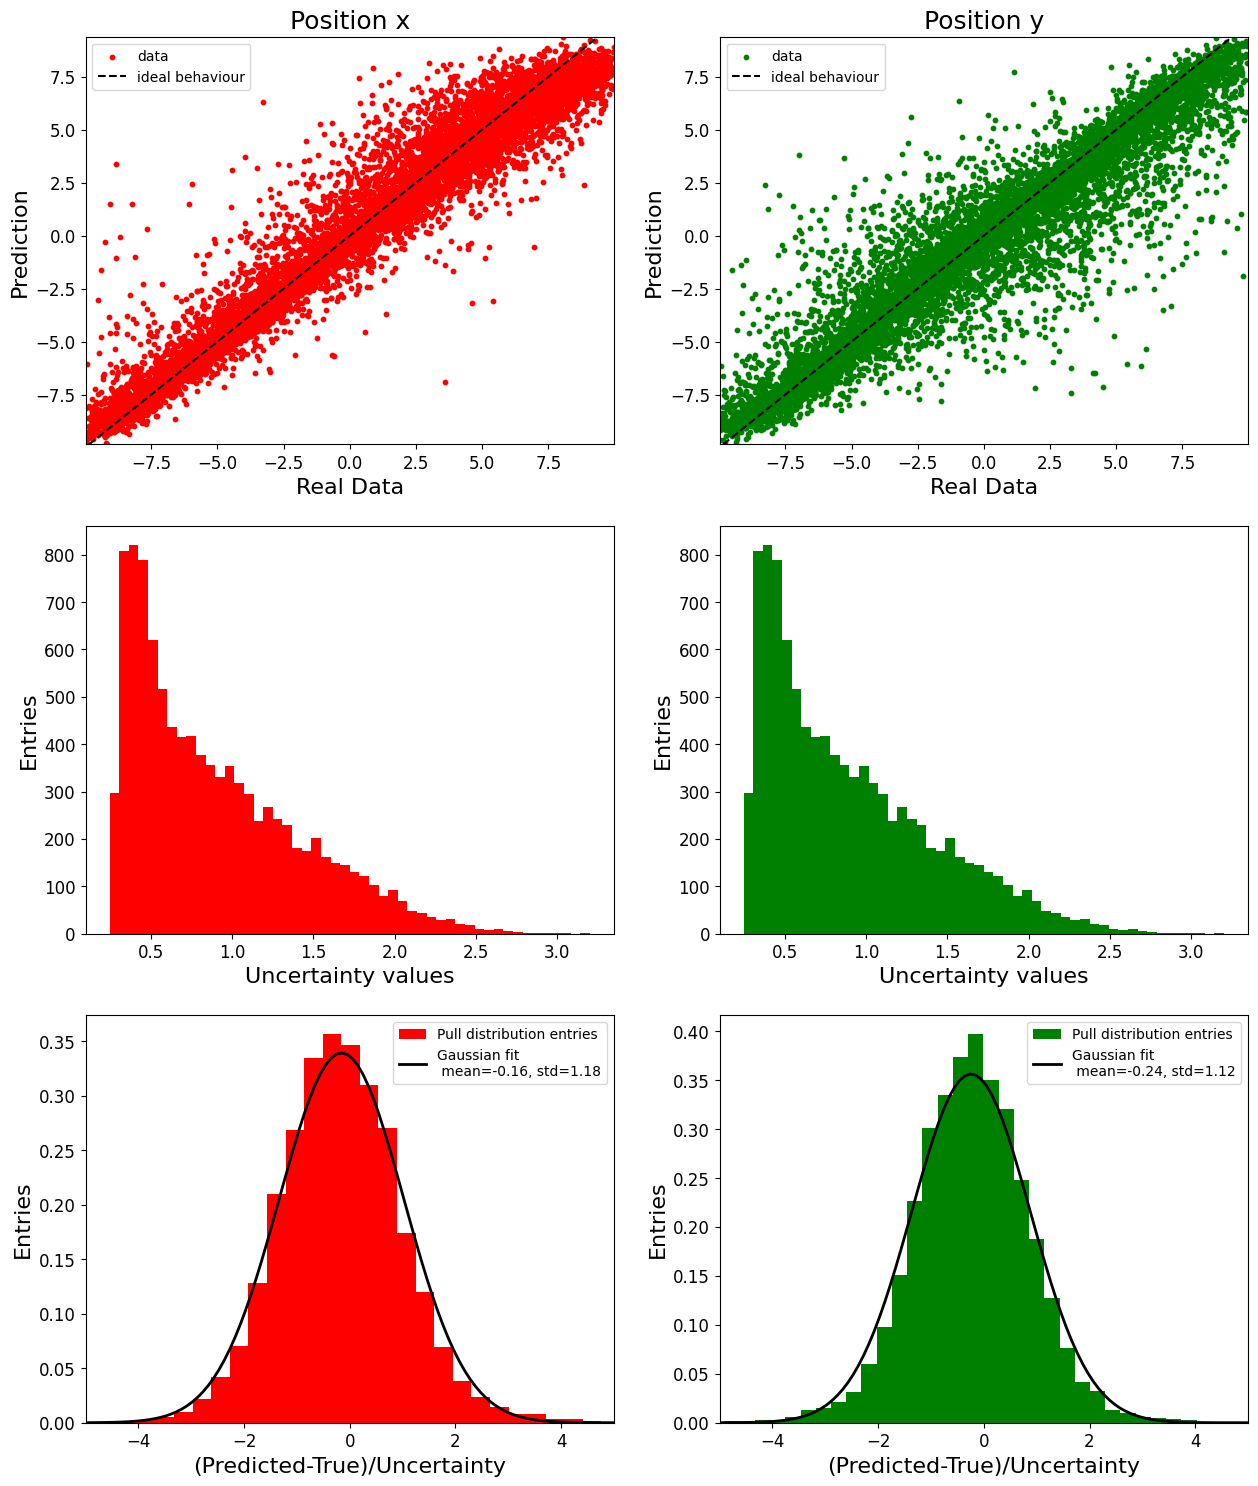

In [57]:
plot_results(denorm_true_labels_3, denorm_predictions_3, labels_name, denorm_std_3, colors)

In [58]:
DATA_PATH_2 = '/content/drive/My Drive/Advanced_deep_learning/Exercise_4/'

In [59]:
import random

model_3.eval()
with torch.no_grad():

    feature, label = next(iter(test_loader)) #Make the loader an iterable and extract the first available element

    feature = feature.to(device)
    label = label.to(device)

    #Choose three different indexes to pick three random batch elements
    batch_size = len(feature)
    random_indices = random.sample(range(batch_size), k=3)

    # Loop on indeces and visualize the Predicted PDFs
    for idx in random_indices:
        filename = f"{DATA_PATH_2}full_flow_{idx}.png"

        model_3.visualize_pdf(
            input_data=feature,
            filename=filename,
            samplesize=2000,
            batch_index=idx,
            truth=label[idx]
        )